In [9]:
import numpy as np
import pandas as pd
import yaml
from pathlib import Path
import orca

from mazsim import data_loader, variable_loader, control_totals

In [10]:
project_dir = Path.cwd().parent
orca.add_injectable("project_dir", project_dir)
orca.run(['load_settings', 'load_data', 'build_networks','register_variables'])

Running step 'load_settings'
Registered injectable: data_dir: data
Registered injectable: output_dir: output
Registered injectable: data_model: data_model.py
Registered injectable: geography_id: block_id
Registered injectable: base_year: 2020
Registered injectable: end_year: 2050
Registered injectable: calibrated: True
Registered injectable: hh_ct_type: subregional
Registered injectable: job_ct_type: subregional
Registered injectable: housing_vacancy_rate: 0.05
Registered injectable: output_tables: ['households', 'persons', 'jobs', 'housing_units']
Registered injectable: custom_steps_dir: configs
Registered injectable: custom_steps_files: ['custom_steps.py']
Registered injectable: custom_variables_dir: configs
Registered injectable: custom_variables_files: ['custom_variables.py']
Registered injectable: submodel_groups: {'hlcm': {'ct_type': 'hh_ct_type'}, 'hulcm': {'ct_type': 'hh_ct_type', 'unsegmented_injectable': 'reg_hulcm_step_names'}, 'jlcm': {'ct_type': 'job_ct_type', 'unsegmented

In [11]:
from urbansim.models import util
from urbansim_templates import modelmanager as mm
from urbansim_templates.models import LargeMultinomialLogitStep

from urbansim.models.util import (columns_in_filters, columns_in_formula)
from choicemodels.tools import MergedChoiceTable

mm.initialize(Path.joinpath(project_dir, "configs", "submodels"))

Registering model step 'hlcm1'
Registering model step 'hlcm1_calib'
Registering model step 'hlcm2'
Registering model step 'hlcm2_calib'
Registering model step 'hlcm3'
Registering model step 'hlcm3_calib'
Registering model step 'hlcm4'
Registering model step 'hlcm4_calib'
Registering model step 'hulcm1'
Registering model step 'hulcm1_calib'
Registering model step 'hulcm2'
Registering model step 'hulcm2_calib'
Registering model step 'hulcm3'
Registering model step 'hulcm3_calib'
Registering model step 'hulcm4'
Registering model step 'hulcm4_calib'
Registering model step 'hupm_rent'
Registering model step 'hupm_value'
Registering model step 'jlcm1'
Registering model step 'jlcm1_calib'
Registering model step 'jlcm2'
Registering model step 'jlcm2_calib'
Registering model step 'jlcm3'
Registering model step 'jlcm3_calib'
Registering model step 'jlcm4'
Registering model step 'jlcm4_calib'
Registering model step 'jlcm5'
Registering model step 'jlcm5_calib'


In [12]:
import matplotlib.pyplot as plt
%matplotlib notebook
%matplotlib inline

import seaborn as sb

from bokeh.io import output_notebook#, show
# from bokeh.plotting import Figure
# from datashader.bokeh_ext import create_ramp_legend, create_categorical_legend

output_notebook()

import datashader.transfer_functions as tf

import datashader as ds
from datashader.colors import viridis

def visualize_variable(variable_name):
    p = orca.get_table('blocks').to_frame(['x', 'y', variable_name])
    
    cvs = ds.Canvas(plot_width=1000, plot_height=700)
    agg = cvs.points(p, 'x', 'y', ds.mean(variable_name))
    img = tf.set_background(tf.shade(agg, cmap=viridis),"white")
    return img

def summed_probas(sum_variable, probas):
    p = orca.get_table('blocks').to_frame([sum_variable])
    p['proba'] = probas

    summed_puma = p.groupby(sum_variable).proba.sum()

    (summed_puma / summed_puma.sum()).plot(kind='bar')

def plot_probas(proba):
    p = orca.get_table('blocks').to_frame(['x', 'y'])
    p['proba'] = proba

    cvs = ds.Canvas(plot_width=1000, plot_height=700)
    agg = cvs.points(p, 'x', 'y', ds.mean('proba'))
    img= tf.set_background(tf.shade(agg, cmap=viridis),"white")
    return img

def corr_plot(selected_variables):
    cols = []
    for col in selected_variables:    
        if col.startswith('np'):
            cols.append(col.split('(')[-1][:-1])
        else:
            cols.append(col)

    X = orca.get_table('blocks').to_frame(cols)

    plt.subplots(figsize=(12, 12))
    sb.heatmap(X.corr(), annot=True, cmap="RdYlGn")
    plt.show()
    
def skew_plot(selected_variables):
    cols = []
    for col in selected_variables:    
        if col.startswith('np'):
            cols.append(col.split('(')[-1][:-1])
        else:
            cols.append(col)
            
    X = orca.get_table('blocks').to_frame(cols)
    X.skew().plot(kind='bar')

def create_probs_table(m, rep_chooser_filter = None, sample_alts= None, sample_choosers= None,idx='building_id'):
    filter_cols = columns_in_filters(to_str(m.chooser_filters) + " " + to_str(m.alt_filters) + to_str(rep_chooser_filter))
    colnames = columns_in_formula(m.model_expression) + columns_in_filters(filter_cols)
    alts = orca.get_table(m.alternatives).to_frame(colnames)
    alts = alts.query(to_str(m.alt_filters)) if m.alt_filters else alts
    obs = orca.get_table(m.choosers).to_frame(colnames)
    obs = obs.query(to_str(m.chooser_filters)) if m.chooser_filters else obs
    if idx in obs.columns:
        obs = obs.drop(columns=[idx])
    # Filter representative chooser based on rep_chooser_filter input
    if rep_chooser_filter:
        # check if rep_filter has columns from the interaction terms
        if (all(x in obs.columns for x in columns_in_filters(to_str(rep_chooser_filter)))):
            obs = obs.query(to_str(rep_chooser_filter))
        else:
            chooser_vars = [x for x in columns_in_formula(m.model_expression) if x in orca.get_table(m.choosers).columns]
            raise ValueError("Representative choosers' filters must be on these columns:\n *{}".format('\n *'.join(chooser_vars)))
    if sample_choosers:
        if sample_choosers <= len(obs):
            obs = obs.sample(n= sample_choosers)
        else:
            obs
    if len(obs) == 0:
        raise ValueError('No choosers left after filtering.')
    if len(alts) == 0:
        raise ValueError('No alternatives left after filtering.')
    
    if not sample_alts:
        sample_alts = len(alts)
    mtc = MergedChoiceTable(obs, alts, sample_size= sample_alts)
    probas = m.model.probabilities(mtc)
    probas = probas.reset_index(level=1).groupby(idx).sum()
    return probas

def to_str(w):
    if isinstance(w, str):
        return w
    if isinstance(w, list):
        return ' & '.join(w) if len(w) > 1 else w[0]
    if not w:
        return " "

Loading BokehJS ...

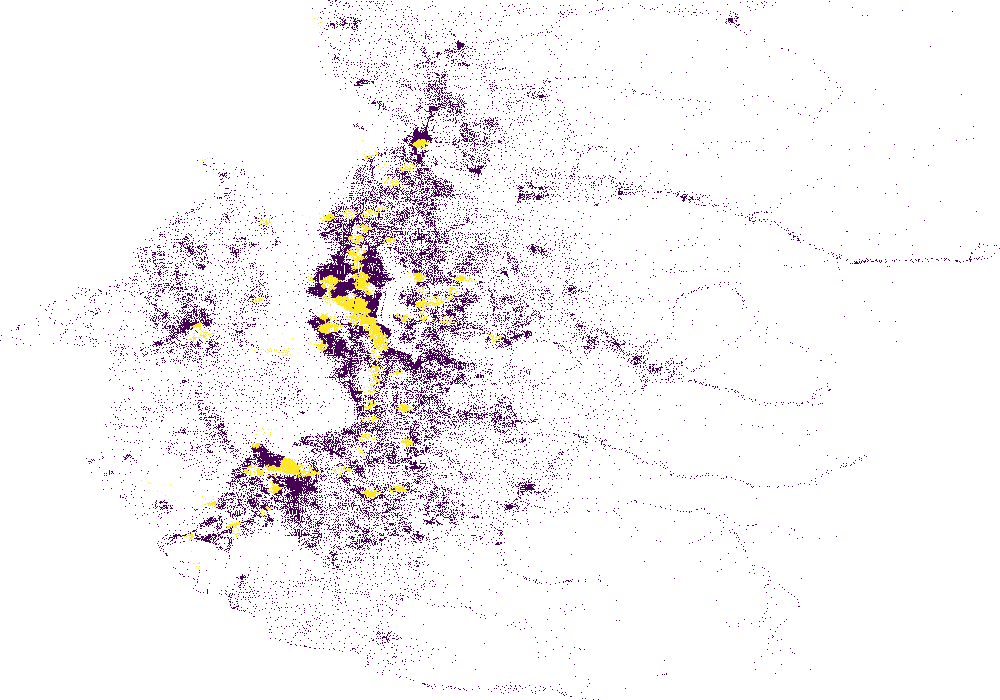

In [53]:
visualize_variable('st_is_transit_stop_sum_1600_flat')

In [54]:
# Set explanatory variables
expl_vars = [
    'major_road_node_sum_800_flat',
    'st_ln_zones_total_jobs_15_minutes_am_single_vehicle_to_work_travel_time',
    'st_prop_aggr_sector_id_1_ave_1600_flat', 
    'st_prop_aggr_sector_id_2_ave_1600_flat', 
    'st_prop_aggr_sector_id_3_ave_1600_flat',
    'st_prop_aggr_sector_id_4_ave_1600_flat',
    'st_prop_aggr_sector_id_5_ave_1600_flat',
    'st_ln_res_value_ave_1600_flat', 
    'st_ln_res_rent_ave_800_flat',
    'st_total_households_sum_2000_flat',                    
    # 'st_block_groups_median_year_built',
    'st_is_transit_stop_sum_1600_flat',
    # 'st_block_groups_median_income', 
    'sum_sf_built_prev_10_years_ave_1600_flat', 
    'sum_mf_built_prev_10_years_ave_800_flat',
    'st_prop_children_0_ave_400_flat',
    'st_sum_income_ave_1600_flat'
]

In [ ]:
corr_plot(expl_vars)

In [ ]:
# hulcm1: Single-family owner housing units
m = LargeMultinomialLogitStep()
m.choosers = ['housing_units']
m.chooser_sample_size = 5000
m.chooser_filters = '(year_built > 2010) & (unit_type_id == 1)'
m.alternatives = ['blocks']
m.choice_column = 'block_id'
m.constrained_choices = True
m.alt_sample_size = 50 
m.out_chooser_filters = '(block_id == "-1") & (year_built > 2010) & (unit_type_id == 1)'
m.alt_capacity = 'vacant_du_spaces'
m.out_alt_filters = 'vacant_du_spaces > 0'
m.model_expression = util.str_model_expression(expl_vars, add_constant=False)
m.fit()
m.name = 'hulcm1'

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          5,000
Model:         Multinomial Logit   Df Residuals:              4,983
Method:       Maximum Likelihood   Df Model:                     17
Date:                 2026-09-17   Pseudo R-squ.:             0.173
Time:                      11:34   Pseudo R-bar-squ.:         0.172
AIC:                  32,399.938   Log-Likelihood:      -16,182.969
BIC:                  32,510.730   LL-Null:             -19,560.115
                                                                             coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------------------------------------------------
major_road_node_sum_800_flat                                              -0.1271     0.027    -4.693     0.000             
st_ln_zones_total_jobs_15_minutes_am_single_vehicle_to_work_travel_time   -0.0662

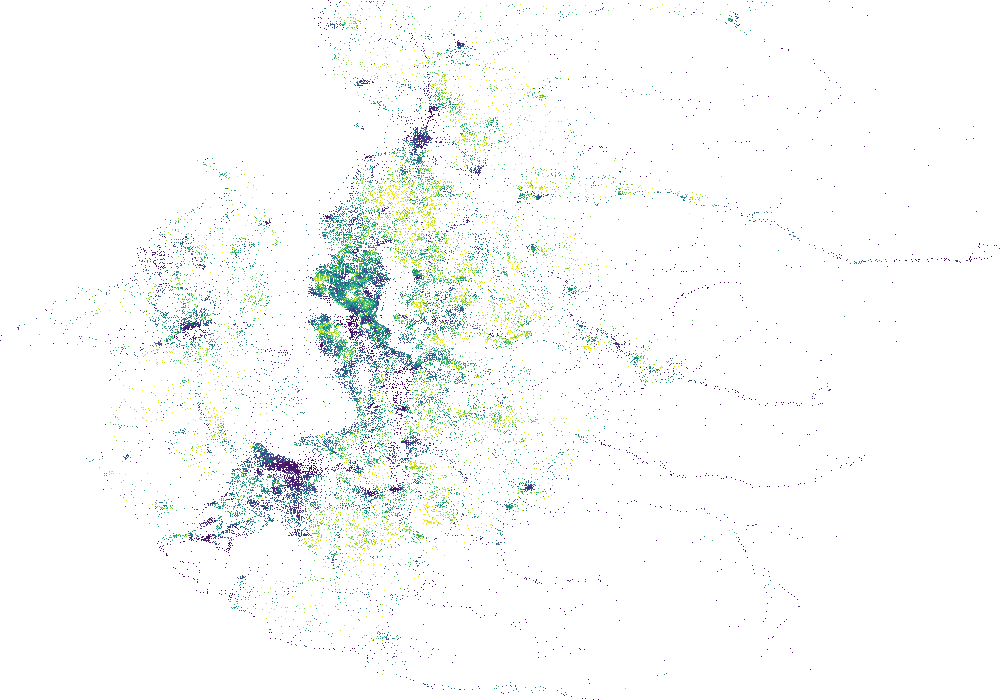

In [16]:
proba = create_probs_table(m, sample_choosers= 1, idx='block_id')
plot_probas(proba)

In [ ]:
# register model (will overwrite previous model)
mm.register(m)

In [27]:
# hulcm2: Single-family renter housing units
m = LargeMultinomialLogitStep()
m.choosers = ['housing_units']
# m.chooser_sample_size = 1000
m.chooser_filters = '(year_built > 2010) & (unit_type_id == 2)'
m.alternatives = ['blocks']
m.choice_column = 'block_id'
m.constrained_choices = True
m.alt_sample_size = 50 
m.out_chooser_filters = '(block_id == "-1") & (year_built > 2010) & (unit_type_id == 2)'
m.alt_capacity = 'vacant_du_spaces_clip'
m.out_alt_filters = 'vacant_du_spaces_clip > 0'
m.model_expression = util.str_model_expression(expl_vars, add_constant=False)
m.fit()
m.name = 'hulcm2'

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:            554
Model:         Multinomial Logit   Df Residuals:                537
Method:       Maximum Likelihood   Df Model:                     17
Date:                 2026-09-17   Pseudo R-squ.:             0.360
Time:                      11:36   Pseudo R-bar-squ.:         0.352
AIC:                   2,809.124   Log-Likelihood:       -1,387.562
BIC:                   2,882.516   LL-Null:              -2,167.261
                                                                             coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------------------------------------------------
major_road_node_sum_800_flat                                               0.0953     0.062     1.540     0.124             
st_ln_zones_total_jobs_15_minutes_am_single_vehicle_to_work_travel_time   -0.4110

In [ ]:
# register model (will overwrite previous model)
mm.register(m)

In [28]:
# hulcm3: Multi-family owner housing units
m = LargeMultinomialLogitStep()
m.choosers = ['housing_units']
# m.chooser_sample_size = 5000
m.chooser_filters = '(year_built > 2010) & (unit_type_id == 3)'
m.alternatives = ['blocks']
m.choice_column = 'block_id'
m.constrained_choices = True
m.alt_sample_size = 50 
m.out_chooser_filters = '(block_id == "-1") & (year_built > 2010) & (unit_type_id == 3)'
m.alt_capacity = 'vacant_du_spaces_clip'
m.out_alt_filters = 'vacant_du_spaces_clip > 0'
m.model_expression = util.str_model_expression(expl_vars, add_constant=False)
m.fit()
m.name = 'hulcm3'

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,287
Model:         Multinomial Logit   Df Residuals:              2,270
Method:       Maximum Likelihood   Df Model:                     17
Date:                 2026-09-17   Pseudo R-squ.:             0.210
Time:                      11:36   Pseudo R-bar-squ.:         0.208
AIC:                  14,162.795   Log-Likelihood:       -7,064.397
BIC:                  14,260.290   LL-Null:              -8,946.797
                                                                             coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------------------------------------------------
major_road_node_sum_800_flat                                              -0.2478     0.034    -7.234     0.000             
st_ln_zones_total_jobs_15_minutes_am_single_vehicle_to_work_travel_time   -0.1924

In [ ]:
# register model (will overwrite previous model)
mm.register(m)

In [55]:
# hulcm4: Multi-family renter housing units
m = LargeMultinomialLogitStep()
m.choosers = ['housing_units']
m.chooser_sample_size = 5000
m.chooser_filters = '(year_built > 2010) & (unit_type_id == 4)'
m.alternatives = ['blocks']
m.choice_column = 'block_id'
m.constrained_choices = True
m.alt_sample_size = 50 
m.out_chooser_filters = '(block_id == "-1") & (year_built >= 2010) & (unit_type_id == 4)'
m.alt_capacity = 'vacant_du_spaces_clip'
m.out_alt_filters = 'vacant_du_spaces_clip > 0'
m.model_expression = util.str_model_expression(expl_vars, add_constant=False)
m.fit()
m.name = 'hulcm4'

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          5,000
Model:         Multinomial Logit   Df Residuals:              4,985
Method:       Maximum Likelihood   Df Model:                     15
Date:                 2026-09-17   Pseudo R-squ.:             0.302
Time:                      12:09   Pseudo R-bar-squ.:         0.301
AIC:                  27,338.886   Log-Likelihood:      -13,654.443
BIC:                  27,436.644   LL-Null:             -19,560.115
                                                                             coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------------------------------------------------
major_road_node_sum_800_flat                                               0.0475     0.017     2.823     0.005             
st_ln_zones_total_jobs_15_minutes_am_single_vehicle_to_work_travel_time    0.3030

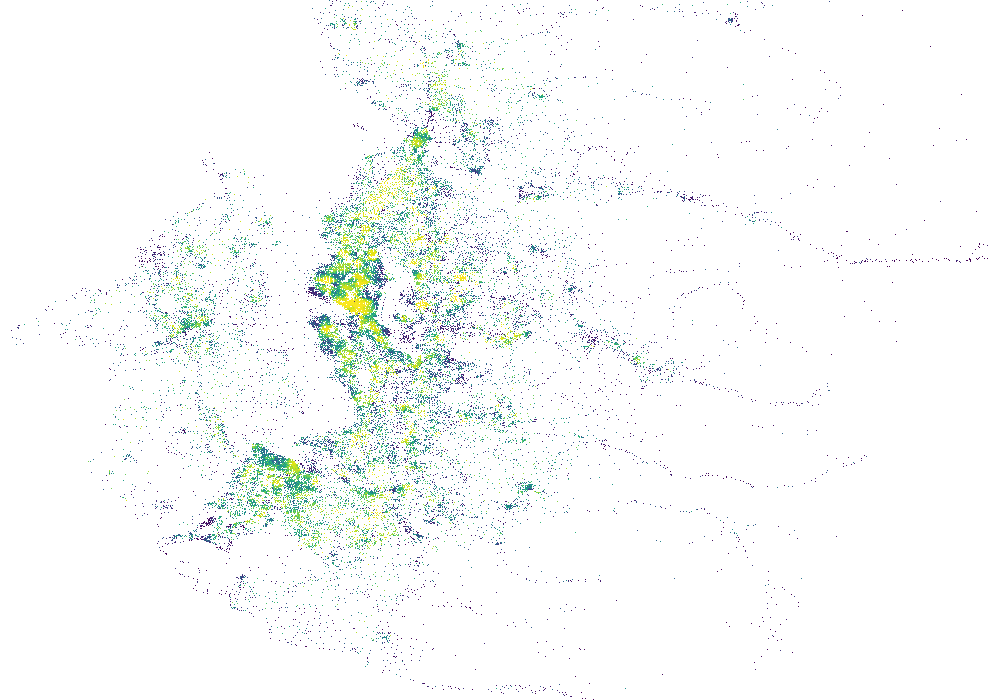

In [56]:
proba = create_probs_table(m, sample_choosers= 1, idx='block_id')
plot_probas(proba)

In [31]:
tract_proba = proba.reset_index().assign(tract_id = lambda x: x['block_id'].astype(str).str[:12].astype('int64')).groupby('tract_id').mean().reset_index()
tract_proba['rank'] = tract_proba['prob'].rank()
tract_proba.loc[tract_proba['tract_id'] == 153053070208]

,tract_id,block_id,prob,rank
604,153053070208,1.530531e+15,0.000009,339.0


In [ ]:
# register model (will overwrite previous model)
mm.register(m)